# Notebook 05 — Purchasing Trends Analysis
**Author:** Adeesha  
**Role:** Documentation & Visualisation  
**Task:** Load cleaned data from HDFS → Analyse purchasing trends → Produce report-quality charts → Save outputs

---

**Covers:**
- Monthly revenue & order count trends
- Quarterly revenue by year  
- Average order value trend  
- Top 5 products per top international country  
- Customer loyalty & retention analysis

## 1. Load Packages

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

os.makedirs("output/trends", exist_ok=True)

# Consistent chart styling across all charts
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"]       = 130
plt.rcParams["font.family"]       = "DejaVu Sans"
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.labelsize"]    = 11
plt.rcParams["xtick.labelsize"]   = 10
plt.rcParams["ytick.labelsize"]   = 10

BLUE_DARK  = "#0D47A1"
BLUE_MID   = "#1565C0"
BLUE_LIGHT = "#64B5F6"

print("Packages loaded.")

Packages loaded.


## 2. Start Spark Session

In [2]:
spark = SparkSession.builder \
    .appName("RetailTrendsAnalysis") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/26 22:22:36 WARN Utils: Your hostname, Pasindus-MacBook-Pro-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.8.118 instead (on interface en0)
26/04/26 22:22:36 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 22:22:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/26 22:22:37 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Spark version: 4.1.1


## 3. Load Cleaned Dataset from Hadoop HDFS

In [3]:
# Load cleaned Parquet saved by Notebook 01
df = spark.read.parquet("hdfs://localhost:8020/retail/cleaned/")
df.cache()   # cache — reused across all chart cells

print(f"Loaded {df.count():,} records from HDFS.")
print(f"Columns: {df.columns}")
df.show(3, truncate=True)

Loaded 779,425 records from HDFS.
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Year', 'Month', 'DayOfWeek', 'Hour', 'YearMonth', 'TotalPrice']
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Year|Month|DayOfWeek|Hour|YearMonth|TotalPrice|
+-------+---------+--------------------+--------+-------------------+---------+----------+--------------+----+-----+---------+----+---------+----------+
| 489437|    10002|INFLATABLE POLITI...|      12|2009-12-01 09:08:00|     0.85|     15362|United Kingdom|2009|   12|        3|   9|  2009-12|      10.2|
| 489465|   72760B|VINTAGE CREAM 3 B...|       4|2009-12-01 10:52:00|     9.95|     13767|United Kingdom|2009|   12|        3|  10|  2009-12|      39.8|
| 489465|    84879|ASS

## 4. Chart 1 — Monthly Revenue & Order Count Trends

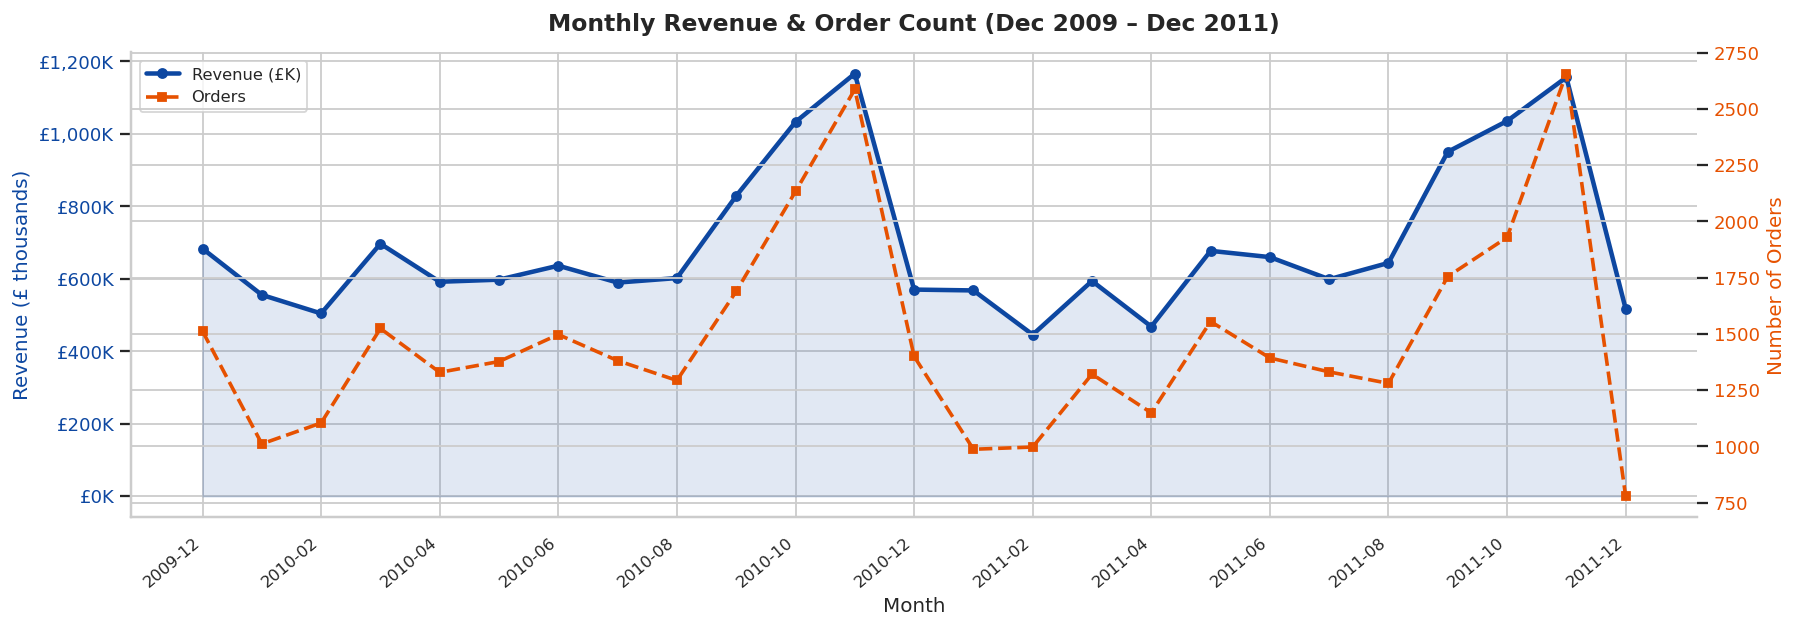

Chart 1 saved.


In [4]:
# Revenue and order count by month — sorted chronologically
monthly = df.groupBy("YearMonth") \
    .agg(
        F.round(F.sum("TotalPrice"), 2).alias("Revenue"),
        F.countDistinct("Invoice").alias("OrderCount")
    ) \
    .orderBy("YearMonth") \
    .toPandas()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Revenue — shaded area + line on left axis
ax1.fill_between(monthly["YearMonth"], monthly["Revenue"] / 1e3,
                 alpha=0.12, color=BLUE_DARK)
ax1.plot(monthly["YearMonth"], monthly["Revenue"] / 1e3,
         color=BLUE_DARK, linewidth=2.5, marker="o", markersize=5, label="Revenue (£K)")

# Order count — dashed line on right axis
ax2.plot(monthly["YearMonth"], monthly["OrderCount"],
         color="#E65100", linewidth=2, marker="s", markersize=4,
         linestyle="--", label="Orders")

ax1.set_ylabel("Revenue (£ thousands)", color=BLUE_DARK)
ax2.set_ylabel("Number of Orders",      color="#E65100")
ax1.tick_params(axis="y", labelcolor=BLUE_DARK)
ax2.tick_params(axis="y", labelcolor="#E65100")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))

# Show every other x-label to avoid crowding
labels = monthly["YearMonth"].tolist()
ax1.set_xticks(range(0, len(labels), 2))
ax1.set_xticklabels(labels[::2], rotation=40, ha="right", fontsize=9)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc="upper left", fontsize=9)

ax1.set_title("Monthly Revenue & Order Count (Dec 2009 – Dec 2011)",
              fontweight="bold", pad=12)
ax1.set_xlabel("Month")

plt.tight_layout()
plt.savefig("output/trends/chart_monthly_trends.png", bbox_inches="tight")
plt.show()
print("Chart 1 saved.")

monthly.to_csv("output/trends/monthly_trends.csv", index=False)

**Interpretation:** Revenue grew across the two-year period, with a clear November peak each year driven by pre-Christmas gift purchasing. Order count follows the same seasonal pattern closely, indicating that volume growth (more orders) is a key contributor to revenue growth — though changes in average order value or product mix may also play a role. The January drop-off is sharp each year, reflecting the post-holiday slowdown typical in gifting retail. November 2011 is the single highest revenue month in the entire dataset.


## 5. Chart 2 — Quarterly Revenue by Year

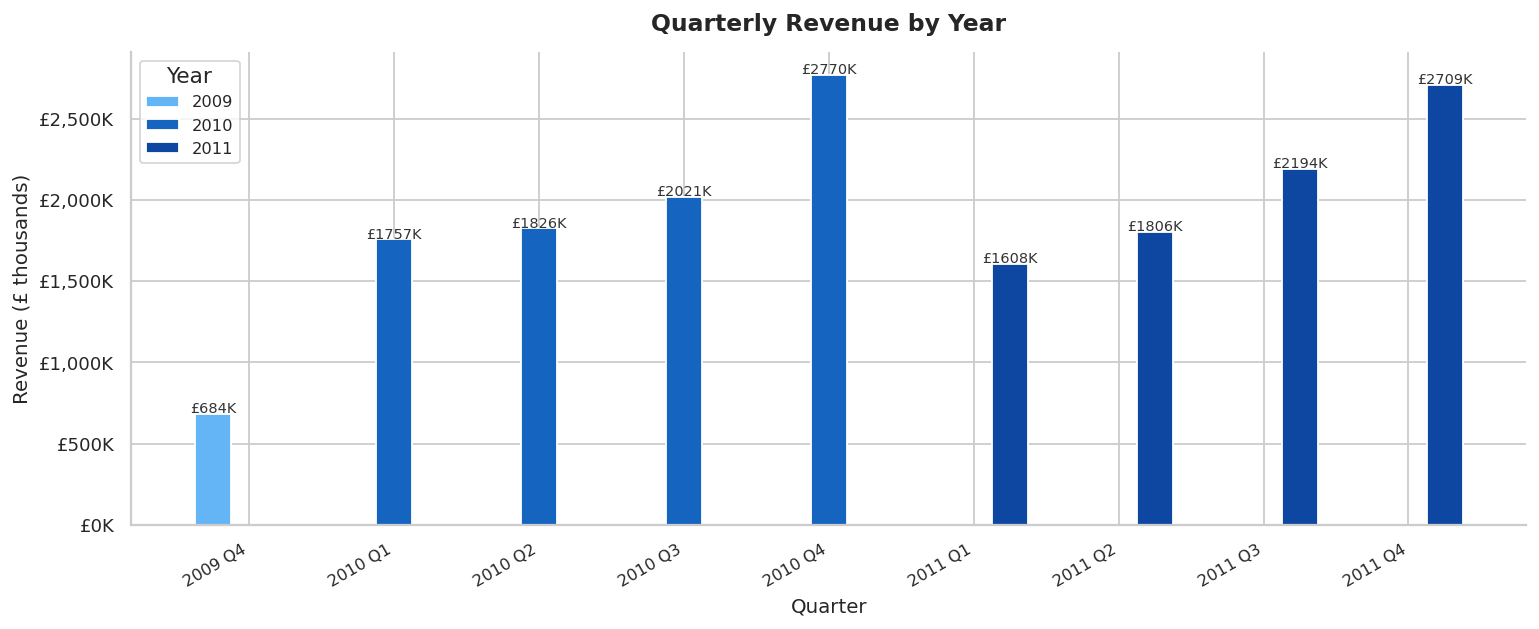

Chart 2 saved.


In [5]:
# Quarterly revenue — group by year and quarter
quarterly = df \
    .withColumn(
        "Quarter",
        F.concat(
            F.col("Year").cast("string"),
            F.lit(" Q"),
            F.ceil(F.col("Month") / 3).cast("string")
        )
    ) \
    .groupBy("Year", "Quarter") \
    .agg(
        F.round(F.sum("TotalPrice"), 2).alias("Revenue"),
        F.countDistinct("Invoice").alias("Orders")
    ) \
    .orderBy("Quarter") \
    .toPandas()

years  = sorted(quarterly["Year"].unique())
q_vals = sorted(quarterly["Quarter"].unique())
colors = [BLUE_LIGHT, BLUE_MID, BLUE_DARK]
width  = 0.25
x_idx  = range(len(q_vals))

fig, ax = plt.subplots(figsize=(12, 5))

for i, (year, color) in enumerate(zip(years, colors)):
    sub = quarterly[quarterly["Year"] == year].set_index("Quarter").reindex(q_vals)
    positions = [xi + i * width for xi in x_idx]
    bars = ax.bar(positions, sub["Revenue"].fillna(0) / 1e3,
                  width=width, color=color, edgecolor="white", label=str(year))
    for bar in bars:
        h = bar.get_height()
        if h > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 5,
                f"£{h:.0f}K", ha="center", fontsize=8, color="#333"
            )

ax.set_xticks([xi + width for xi in x_idx])
ax.set_xticklabels(q_vals, rotation=30, ha="right", fontsize=9)
ax.set_title("Quarterly Revenue by Year", fontweight="bold", pad=12)
ax.set_ylabel("Revenue (£ thousands)")
ax.set_xlabel("Quarter")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}K"))
ax.legend(title="Year", fontsize=9)

plt.tight_layout()
plt.savefig("output/trends/chart_quarterly.png", bbox_inches="tight")
plt.show()
print("Chart 2 saved.")

quarterly.to_csv("output/trends/quarterly_trends.csv", index=False)

**Interpretation:** Q4 (Oct–Dec) is consistently the strongest quarter in every year — confirming the Christmas gifting season drives the business. Q1 (Jan–Mar) is typically the weakest quarter, reflecting the sharp post-holiday slowdown visible in the monthly trend chart each January. Year-on-year growth is visible across all quarters from 2010 to 2011, with Q4 2011 being the highest single quarter in the dataset. Note that the 2009 data covers only December (Q4), so year-on-year comparisons for 2009 are limited to that quarter.


## 6. Chart 3 — Average Order Value Trend

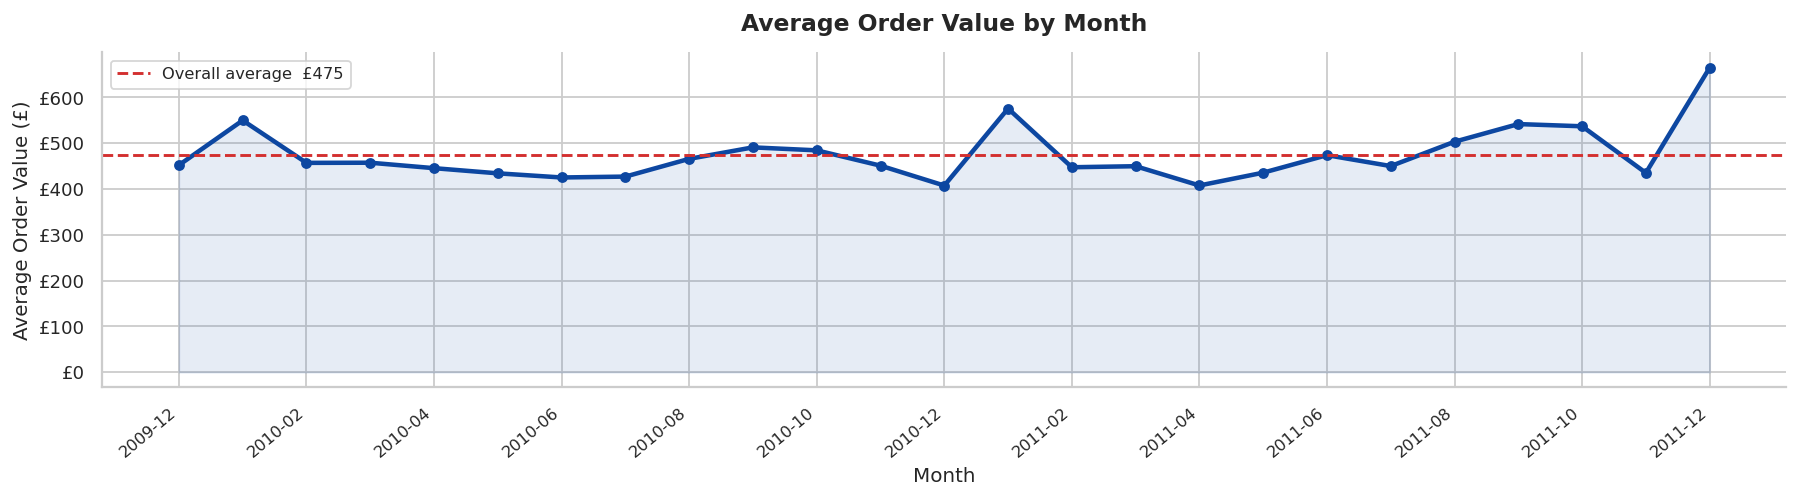

Chart 3 saved.


In [6]:
# Average order value = average total revenue per Invoice per month
aov = df.groupBy("Invoice", "YearMonth") \
    .agg(F.round(F.sum("TotalPrice"), 2).alias("OrderValue")) \
    .groupBy("YearMonth") \
    .agg(F.round(F.avg("OrderValue"), 2).alias("AvgOrderValue")) \
    .orderBy("YearMonth") \
    .toPandas()

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(aov["YearMonth"], aov["AvgOrderValue"],
        color=BLUE_DARK, linewidth=2.5, marker="o", markersize=5)
ax.fill_between(aov["YearMonth"], aov["AvgOrderValue"],
                alpha=0.10, color=BLUE_DARK)

# Overall average reference line
mean_aov = aov["AvgOrderValue"].mean()
ax.axhline(mean_aov, color="#D32F2F", linestyle="--", linewidth=1.6,
           label=f"Overall average  £{mean_aov:.0f}")

ax.set_title("Average Order Value by Month", fontweight="bold", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Average Order Value (£)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:.0f}"))

labels = aov["YearMonth"].tolist()
ax.set_xticks(range(0, len(labels), 2))
ax.set_xticklabels(labels[::2], rotation=40, ha="right", fontsize=9)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("output/trends/chart_avg_order_value.png", bbox_inches="tight")
plt.show()
print("Chart 3 saved.")

aov.to_csv("output/trends/avg_order_value_trend.csv", index=False)

**Interpretation:** Average order value fluctuates around the overall mean, with clear seasonal spikes in October–November each year. These spikes align with the pre-Christmas period and suggest that customers tend to place larger orders as the holiday season approaches. Most months remain close to the overall mean, indicating that the elevated AOV in Q4 is a seasonal rather than a structural shift. To determine whether the spikes are driven by a small number of unusually large orders or by a broad uplift across many customers, a per-invoice distribution analysis within those months would be needed.


## 7. Chart 4 — Top 5 Products by Country (Top 5 International Markets)

Top 5 international markets: ['EIRE', 'Netherlands', 'Germany', 'France', 'Australia']


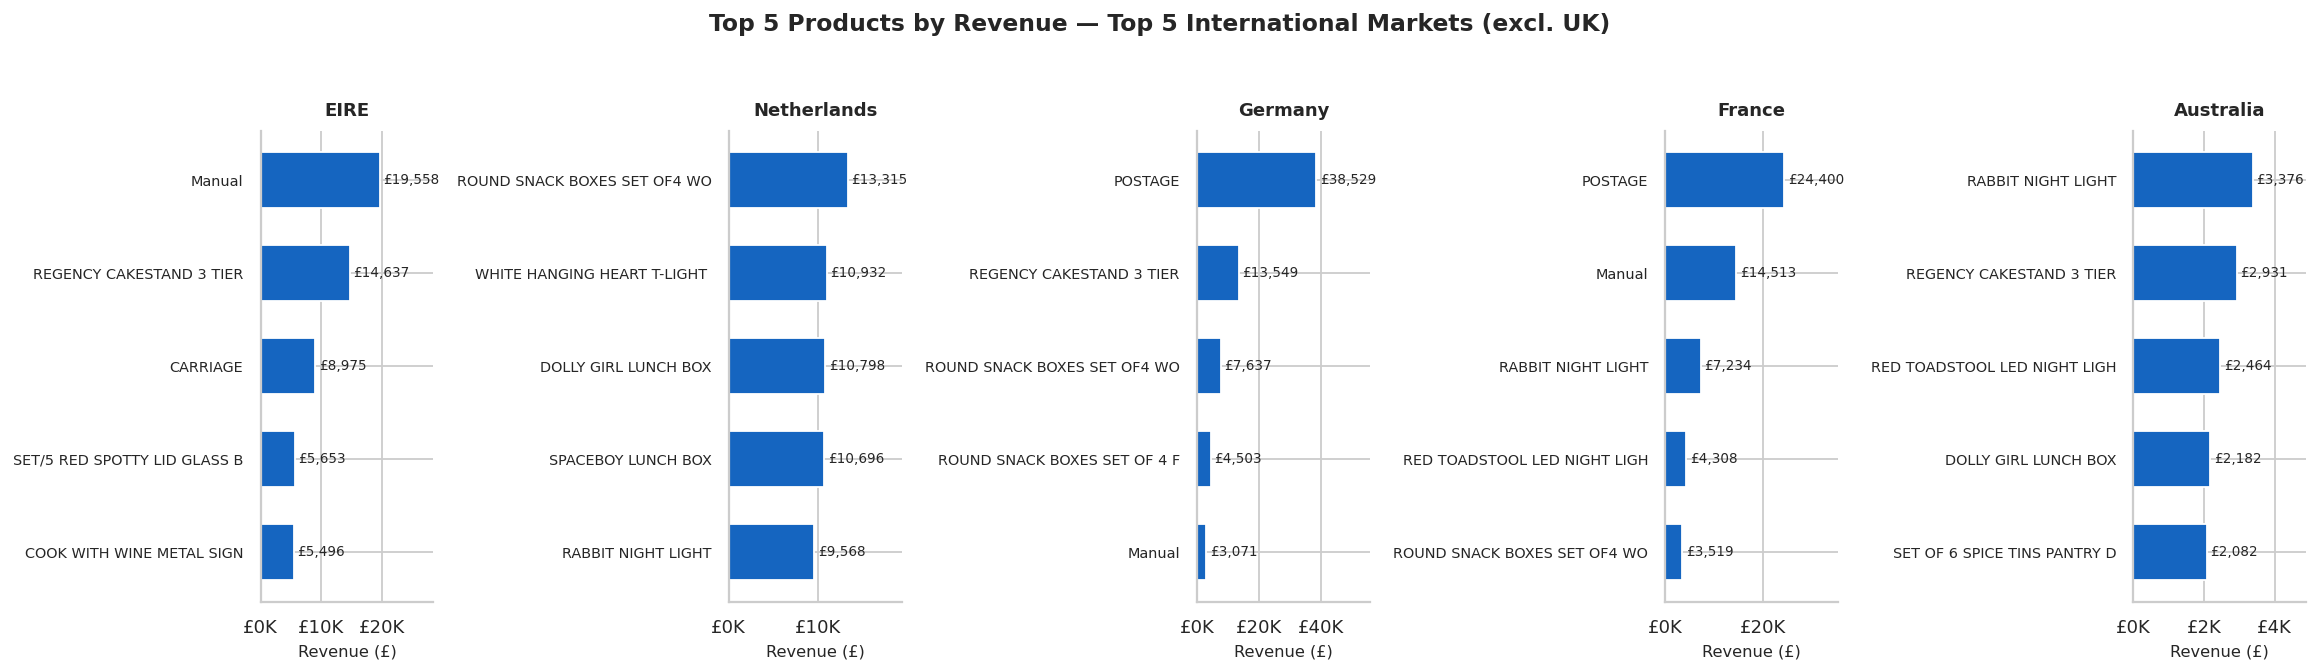

Chart 4 saved.


In [7]:
# Top 5 international countries by revenue (UK excluded to show international patterns)
top5_countries = df \
    .filter(F.col("Country") != "United Kingdom") \
    .groupBy("Country") \
    .agg(F.sum("TotalPrice").alias("Rev")) \
    .orderBy(F.col("Rev").desc()) \
    .limit(5) \
    .toPandas()["Country"].tolist()

print(f"Top 5 international markets: {top5_countries}")

# Rank products within each country using a Window function
window = Window.partitionBy("Country").orderBy(F.col("Revenue").desc())

top5_by_country = df \
    .filter(F.col("Country").isin(top5_countries)) \
    .groupBy("Country", "Description") \
    .agg(F.round(F.sum("TotalPrice"), 2).alias("Revenue")) \
    .withColumn("Rank", F.rank().over(window)) \
    .filter(F.col("Rank") <= 5) \
    .orderBy("Country", "Rank") \
    .toPandas()

top5_by_country["ShortDesc"] = top5_by_country["Description"].str.strip().str[:28]

# One panel per country — horizontal bars
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, country in zip(axes, top5_countries):
    sub = top5_by_country[top5_by_country["Country"] == country]

    bars = ax.barh(
        sub["ShortDesc"][::-1],
        sub["Revenue"][::-1],
        color=BLUE_MID, edgecolor="white", height=0.6
    )

    max_val = sub["Revenue"].max()
    for bar in bars:
        ax.text(
            bar.get_width() + max_val * 0.03,
            bar.get_y() + bar.get_height() / 2,
            f"£{bar.get_width():,.0f}",
            va="center", fontsize=7.5
        )

    ax.set_title(country, fontweight="bold", fontsize=10, pad=8)
    ax.set_xlabel("Revenue (£)", fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(0, max_val * 1.45)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"£{x/1e3:.0f}K")
    )

plt.suptitle(
    "Top 5 Products by Revenue — Top 5 International Markets (excl. UK)",
    fontsize=13, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.savefig("output/trends/chart_top5_by_country.png", bbox_inches="tight")
plt.show()
print("Chart 4 saved.")

top5_by_country.to_csv("output/trends/top5_products_by_country.csv", index=False)

**Interpretation:** Product preferences differ noticeably by country. While some items (particularly popular decorative sets) appear across multiple markets, others are specific to individual countries — reflecting different cultural buying preferences or catalogue availability. Countries with fewer but higher-value top products may indicate a narrower but more concentrated purchasing pattern, while broader spread across products suggests a more diverse customer base. These country-level breakdowns can directly inform localised product catalogues and targeted marketing campaigns for international expansion.


## 8. Chart 5 — Customer Loyalty & Retention Analysis

In [8]:
# Count orders per customer and classify by loyalty tier
customer_orders = df.groupBy("CustomerID") \
    .agg(
        F.countDistinct("Invoice").alias("NumOrders"),
        F.round(F.sum("TotalPrice"), 2).alias("TotalSpent")
    )

# Assign loyalty tier based on number of orders
customer_typed = customer_orders.withColumn(
    "CustomerType",
    F.when(F.col("NumOrders") == 1, "One-time\n(1 order)")
     .when(F.col("NumOrders") <= 3, "Occasional\n(2–3 orders)")
     .when(F.col("NumOrders") <= 5, "Regular\n(4–5 orders)")
     .otherwise(                    "Loyal\n(6+ orders)")
)

# Summary per tier
tier_order_labels = [
    "One-time\n(1 order)",
    "Occasional\n(2–3 orders)",
    "Regular\n(4–5 orders)",
    "Loyal\n(6+ orders)"
]

type_summary = customer_typed.groupBy("CustomerType") \
    .agg(
        F.count("CustomerID").alias("CustomerCount"),
        F.round(F.avg("TotalSpent"), 2).alias("AvgSpend"),
        F.round(F.sum("TotalSpent"), 2).alias("TotalRevenue")
    ) \
    .toPandas()

type_summary = (
    type_summary
    .set_index("CustomerType")
    .reindex(tier_order_labels)
    .reset_index()
)

print("Customer tier summary:")
print(type_summary.to_string(index=False))

Customer tier summary:
            CustomerType  CustomerCount  AvgSpend  TotalRevenue
     One-time\n(1 order)           1623    345.21     560272.56
Occasional\n(2–3 orders)           1608    995.02    1599996.63
   Regular\n(4–5 orders)            846   1542.99    1305366.27
      Loyal\n(6+ orders)           1801   7723.03   13909168.79


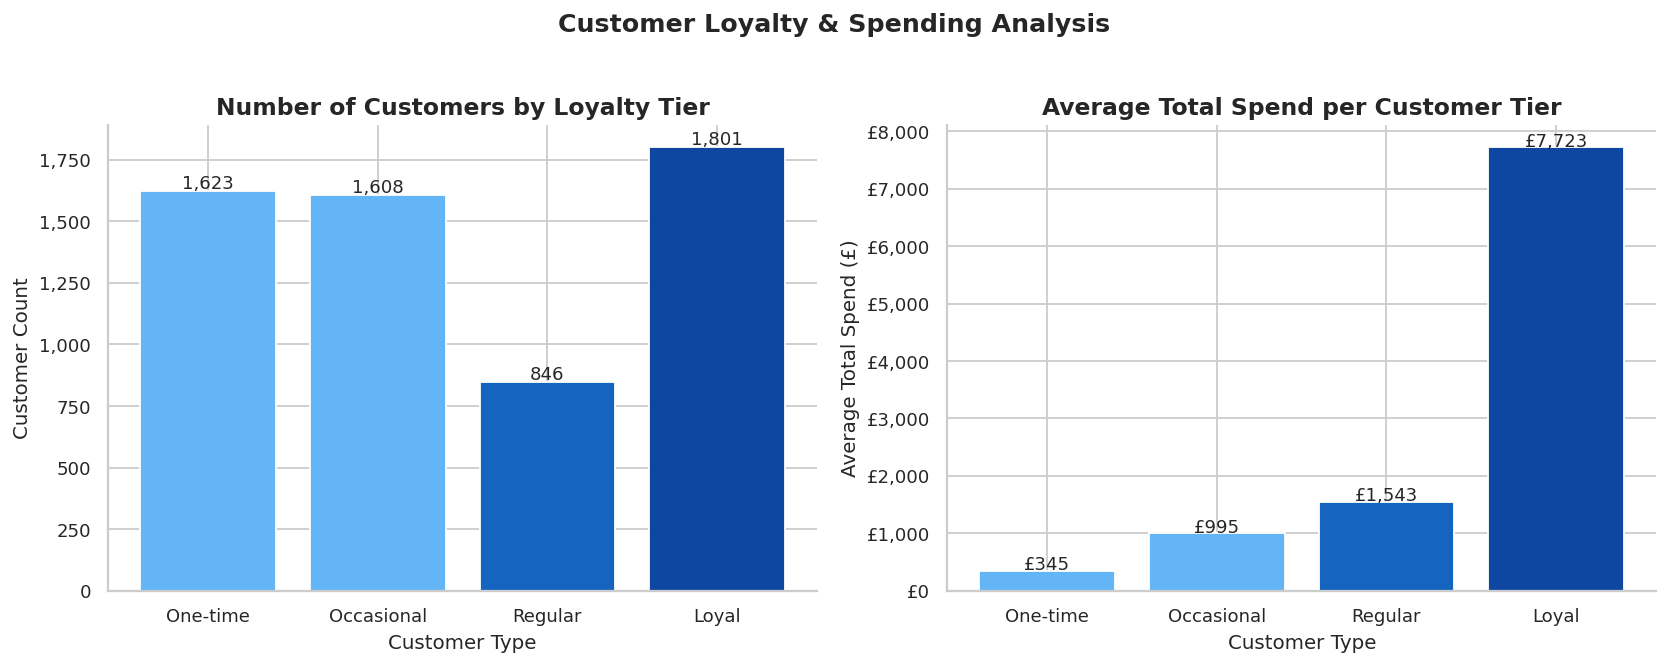

Chart 5 saved.


In [9]:
bar_colors  = [BLUE_LIGHT, "#64B5F6", BLUE_MID, BLUE_DARK]
short_labels = ["One-time", "Occasional", "Regular", "Loyal"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Number of customers per tier ───────────────────────────────────────
bars1 = axes[0].bar(short_labels, type_summary["CustomerCount"],
                    color=bar_colors, edgecolor="white")
for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{int(bar.get_height()):,}",
        ha="center", fontsize=10
    )
axes[0].set_title("Number of Customers by Loyalty Tier", fontweight="bold")
axes[0].set_ylabel("Customer Count")
axes[0].set_xlabel("Customer Type")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ── Right: Average total spend per tier ───────────────────────────────────────
bars2 = axes[1].bar(short_labels, type_summary["AvgSpend"],
                    color=bar_colors, edgecolor="white")
for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f"£{bar.get_height():,.0f}",
        ha="center", fontsize=10
    )
axes[1].set_title("Average Total Spend per Customer Tier", fontweight="bold")
axes[1].set_ylabel("Average Total Spend (£)")
axes[1].set_xlabel("Customer Type")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}")
)

plt.suptitle("Customer Loyalty & Spending Analysis",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("output/trends/chart_customer_retention.png", bbox_inches="tight")
plt.show()
print("Chart 5 saved.")

type_summary.to_csv("output/trends/customer_retention.csv", index=False)

**Interpretation:** Loyal customers (6+ orders) represent a small share of the customer base by count, but their average total spend is substantially higher than one-time buyers. This follows a classic Pareto-like pattern in retail — a small group of loyal customers generates a disproportionate share of total revenue. The tier breakdown also shows that even moving customers from the one-time to the occasional tier produces a meaningful increase in average spend. These findings support investment in loyalty programmes, personalised email campaigns, and exclusive offers for high-order-frequency customers to maximise lifetime value.


## 9. Save All Results to HDFS

In [10]:
# Save monthly trends to HDFS
spark.createDataFrame(monthly).write.parquet(
    "hdfs://localhost:8020/retail/output/trends/monthly/",
    mode="overwrite"
)

# Save quarterly trends to HDFS
spark.createDataFrame(quarterly).write.parquet(
    "hdfs://localhost:8020/retail/output/trends/quarterly/",
    mode="overwrite"
)

print("All trend data saved to HDFS: hdfs://localhost:8020/retail/output/trends/")

# List all saved output files
print("\nLocal output files:")
for root, dirs, files in os.walk("output/trends"):
    for f in sorted(files):
        path = os.path.join(root, f)
        size = os.path.getsize(path)
        print(f"  {path:<55} ({size:,} bytes)")

print("\nNotebook 05 complete.")

All trend data saved to HDFS: hdfs://localhost:8020/retail/output/trends/

Local output files:
  output/trends/avg_order_value_trend.csv                 (396 bytes)
  output/trends/chart_avg_order_value.png                 (59,088 bytes)
  output/trends/chart_customer_retention.png              (67,351 bytes)
  output/trends/chart_monthly_trends.png                  (122,142 bytes)
  output/trends/chart_quarterly.png                       (45,848 bytes)
  output/trends/chart_top5_by_country.png                 (80,409 bytes)
  output/trends/customer_retention.csv                    (236 bytes)
  output/trends/monthly_trends.csv                        (601 bytes)
  output/trends/quarterly_trends.csv                      (287 bytes)
  output/trends/top5_products_by_country.csv              (1,597 bytes)

Notebook 05 complete.


---
## Summary

| Chart | What It Shows | Key Finding |
|-------|--------------|-------------|
| 1. Monthly Trends | Revenue + orders by month | Nov peak; volume growth drives revenue trend |
| 2. Quarterly | Q1–Q4 revenue per year | Q4 dominates every year; Q1 typically weakest |
| 3. Avg Order Value | Average order value over time | Seasonal spikes in Oct–Nov each year |
| 4. Country Products | Top 5 products per country | Different preferences per international market |
| 5. Retention | Customer loyalty tiers vs spend | Loyal customers spend significantly more per head |

**All charts saved to:** `output/trends/`  
**HDFS paths:** `hdfs:///retail/output/trends/monthly/` and `hdfs:///retail/output/trends/quarterly/`
